In [1]:
import numpy as np
import pandas as pd, os, datetime

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.dates as mdates
import folium
from adjustText import adjust_text
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.ticker as mticker

from IPython.display import HTML

In [3]:
profs = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_profile_clusters.csv")

In [4]:
sep = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/DUID_curves.csv")

In [5]:
clustered_info = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_spatial_clusters.csv")

In [6]:
curves = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv')
curves

,cluster,DUID,hour,mean_diff,mean_diff_lower,mean_diff_upper,median_diff,median_diff_lower,median_diff_upper,station_name,cluster_name
0,0,BLUFF1,0,-0.003697,-0.522301,0.480041,0.049484,-0.633376,0.936114,Hallett 5 The Bluff WF,South Australia
1,0,BLUFF1,1,-0.096914,-0.621602,0.396172,-0.059100,-0.758478,0.732758,Hallett 5 The Bluff WF,South Australia
2,0,BLUFF1,2,-0.139565,-0.634625,0.324927,-0.000756,-0.660190,0.573938,Hallett 5 The Bluff WF,South Australia
3,0,BLUFF1,3,-0.153877,-0.637503,0.298114,-0.023986,-0.660983,0.548677,Hallett 5 The Bluff WF,South Australia
4,0,BLUFF1,4,-0.087549,-0.622416,0.368819,0.148777,-0.533313,0.692582,Hallett 5 The Bluff WF,South Australia
...,...,...,...,...,...,...,...,...,...,...,...
1267,5,WOODLWN1,19,0.188764,-0.174150,0.501569,0.434422,-0.064711,0.839480,Woodlawn Wind Farm,Alpine NSW
1268,5,WOODLWN1,20,0.228871,-0.135096,0.555894,0.403211,-0.129037,0.834497,Woodlawn Wind Farm,Alpine NSW
1269,5,WOODLWN1,21,0.250626,-0.116987,0.580623,0.531305,-0.029781,0.964023,Woodlawn Wind Farm,Alpine NSW
1270,5,WOODLWN1,22,0.128097,-0.241891,0.464536,0.242475,-0.193916,0.787894,Woodlawn Wind Farm,Alpine NSW


In [7]:
df = profs.merge(clustered_info[['DUID','cluster','cluster_name','cluster_color']], on='DUID')

In [8]:
cluster_id = 5
dfc = df[df["cluster"] == cluster_id]

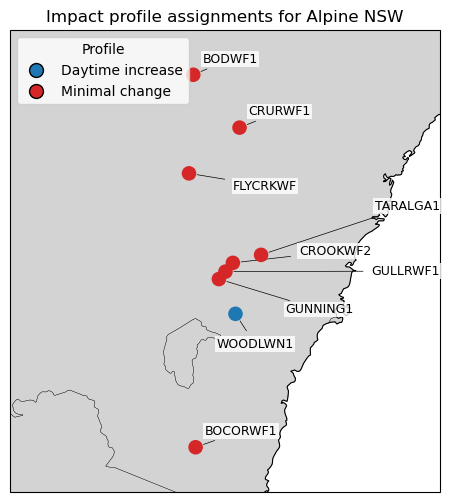

In [12]:
# -------------------
# Auto-zoom extent with padding
# -------------------
pad_lon = 2
pad_lat = 0.5
lon_min, lon_max = dfc["lon"].min() - pad_lon, dfc["lon"].max() + pad_lon
lat_min, lat_max = dfc["lat"].min() - pad_lat, dfc["lat"].max() + pad_lat

# -------------------
# Create figure
# -------------------
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.STATES, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# -------------------
# Plot points
# -------------------
sc = ax.scatter(
    dfc["lon"],
    dfc["lat"],
    c=dfc["profile_color"],
    s=90,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

texts = []
for _, r in dfc.iterrows():
    texts.append(
        ax.text(
            r["lon"],
            r["lat"],
            r["DUID"],
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=6,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
        )
    )

from matplotlib.lines import Line2D

# Create legend entries (one per profile)
legend_df = (
    dfc[["profile_name", "profile_color"]]
    .drop_duplicates()
    .sort_values("profile_name")
)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=row["profile_color"],
        markeredgecolor='black',
        markersize=10,
        label=row["profile_name"],
    )
    for _, row in legend_df.iterrows()
]

ax.legend(
    handles=legend_handles,
    title="Profile",
    loc="upper left",          # or "best"
    frameon=True,
    fontsize=10
)

# -------------------
# Adjust labels to avoid overlap
# -------------------
adjust_text(
    texts,
    x=dfc["lon"].values,          # points to repel from
    y=dfc["lat"].values,
    ax=ax,
    force_text=(0.7, 0.5),        # stronger text–text repulsion
    force_static=(0.8, 0.7),      # stronger text–point repulsion
    expand=(3, 2),            # expand text bboxes for collision
    min_arrow_len=0.3,
    arrowprops=dict(
        arrowstyle="-",
        lw=0.5,
        shrinkA=6,
        shrinkB=6,
    ),
)

# -------------------
# Title
# -------------------
ax.set_title(f'Impact profile assignments for {dfc.iloc[0]["cluster_name"]}')
plt.show()

In [10]:
df_cluster = curves[curves["cluster"] == cluster_id]
df_cluster = df_cluster.merge(
    profs[["DUID", "profile_color", "profile_name"]],
    on="DUID",
    how="left"
)

Text(0.02, 0.5, 'Difference in medians (z-score)')

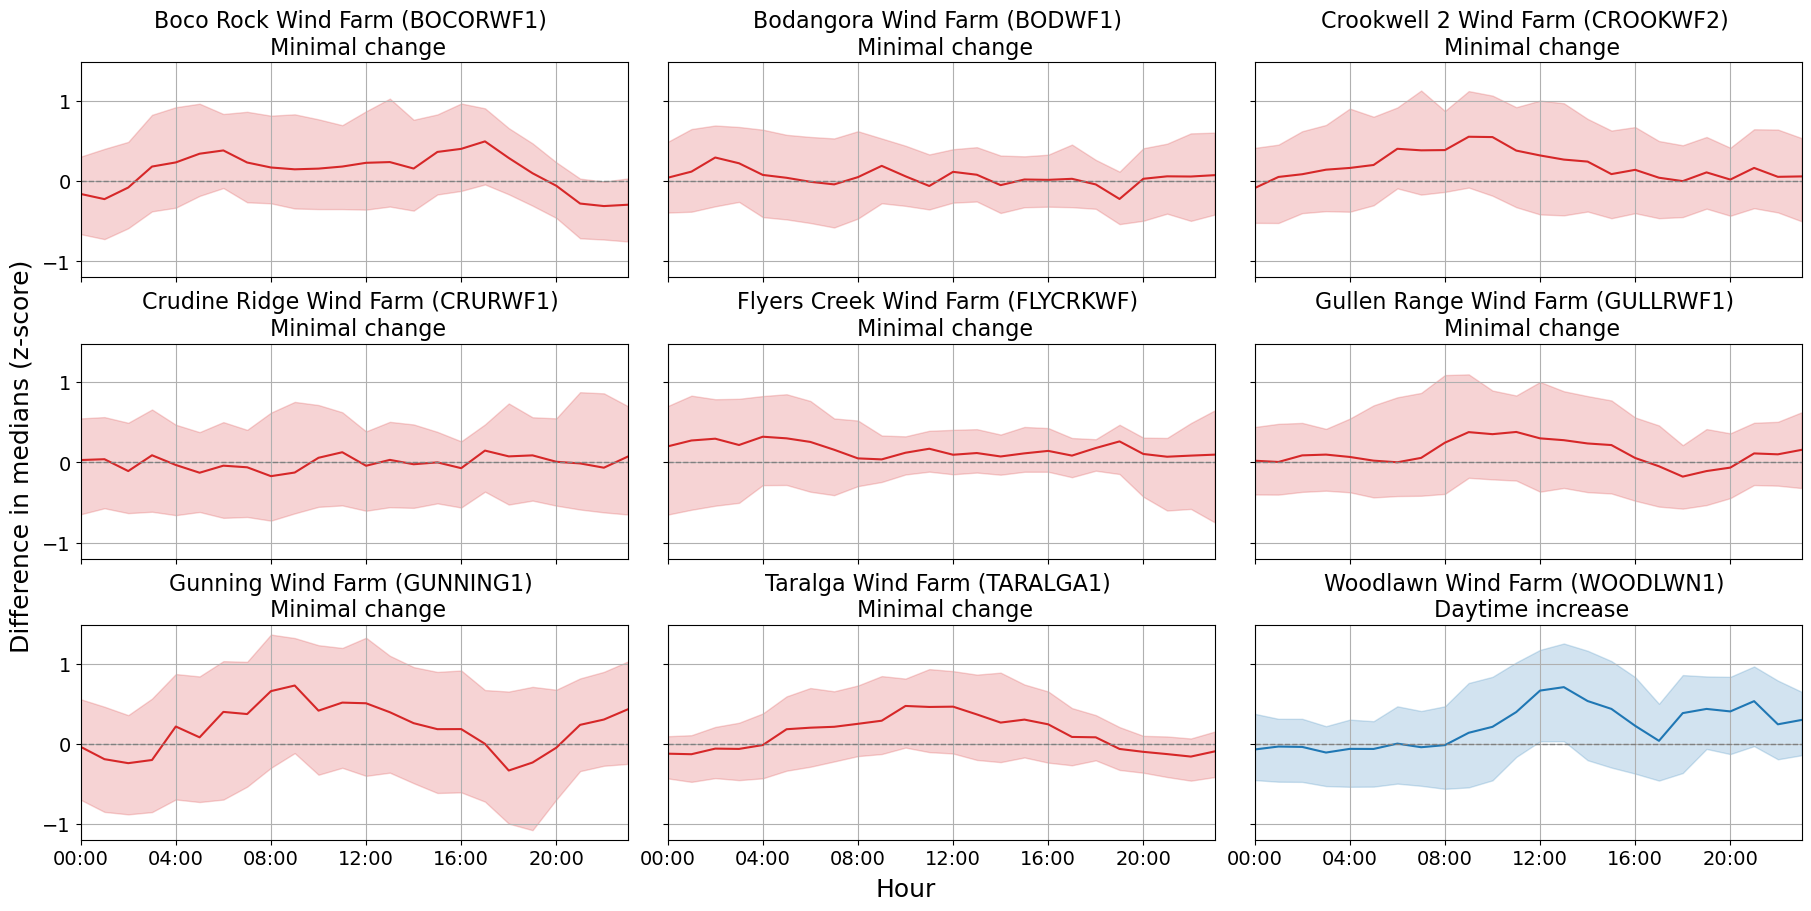

In [11]:
# Unique DUIDs in cluster
duids = df_cluster["DUID"].unique()
n = len(duids)

# Number of columns
ncols = 3
nrows = int(np.ceil(n / ncols))

# Figure and axes (DROP-IN CHANGE: constrained_layout=True)
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 3*nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = axes.flatten()

# Compute global y-limits for the cluster
ymin = df_cluster["median_diff_lower"].min()
ymax = df_cluster["median_diff_upper"].max()
padding = (ymax - ymin) * 0.05
ymin -= padding
ymax += padding

# Plot each DUID
for ax, duid in zip(axes, duids):
    group = df_cluster[df_cluster["DUID"] == duid]

    color = group["profile_color"].iloc[0]

    ax.plot(
        group["hour"],
        group["median_diff"],
        color=color,
        label=duid
    )

    ax.fill_between(
        group["hour"],
        group["median_diff_lower"],
        group["median_diff_upper"],
        color=color,
        alpha=0.2
    )

    ax.set_title(
        f"{group['station_name'].iloc[0]} ({duid}) \n {group['profile_name'].iloc[0]}", fontsize=16
    )

    ax.set_xlim(0, 23)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True)

def hour_formatter(x, pos):
    return f"{int(x):02d}:00"

for ax in axes[:n]:
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))  # every hour
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(hour_formatter))
    ax.tick_params(axis='both', which='major', labelsize=14)

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

# DROP-IN: global axis labels
fig.supxlabel("Hour", fontsize=18)
fig.supylabel("Difference in medians (z-score)", fontsize=18)

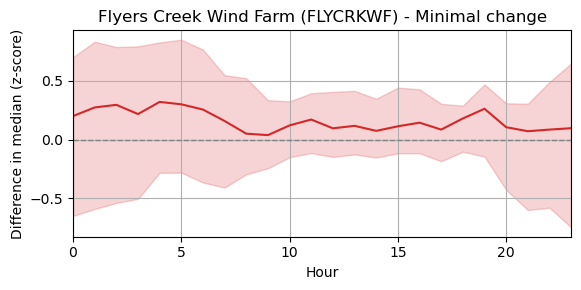

In [12]:
# Specify the DUID you want
selected_duid = "FLYCRKWF"

# Filter dataframe
df_single = df_cluster[df_cluster["DUID"] == selected_duid]

if df_single.empty:
    raise ValueError(f"No data found for DUID: {selected_duid}")

# Unique DUIDs (will be 1)
duids = df_single["DUID"].unique()
n = len(duids)

# Subplot layout (force 1 plot)
ncols = 1
nrows = 1

# Figure and axes
fig, ax = plt.subplots(figsize=(6, 3))

# Compute global y-limits (from the single DUID)
ymin = df_single["median_diff_lower"].min()
ymax = df_single["median_diff_upper"].max()
padding = (ymax - ymin) * 0.05
ymin -= padding
ymax += padding

# Plot
group = df_single

ax.plot(
    group["hour"],
    group["median_diff"],
    color=group["profile_color"].iloc[0],
    label=selected_duid
)

ax.fill_between(
    group["hour"],
    group["median_diff_lower"],
    group["median_diff_upper"],
    color=group["profile_color"].iloc[0],
    alpha=0.2
)

ax.set_title(
    f"{group['station_name'].iloc[0]} ({selected_duid}) - {group['profile_name'].iloc[0]}"
)

ax.set_ylabel("Difference in median (z-score)")
ax.set_xlabel("Hour")
ax.set_ylim(ymin, ymax)
ax.set_xlim(0,23)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(True)

plt.tight_layout()
plt.show()


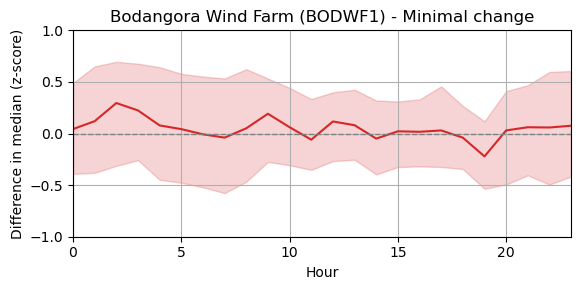

In [13]:
# Specify the DUID you want
selected_duid = "BODWF1"

# Filter dataframe
df_single = df_cluster[df_cluster["DUID"] == selected_duid]

if df_single.empty:
    raise ValueError(f"No data found for DUID: {selected_duid}")

# Unique DUIDs (will be 1)
duids = df_single["DUID"].unique()
n = len(duids)

# Subplot layout (force 1 plot)
ncols = 1
nrows = 1

# Figure and axes
fig, ax = plt.subplots(figsize=(6, 3))

# Compute global y-limits (from the single DUID)
ymin = df_single["median_diff_lower"].min()
ymax = df_single["median_diff_upper"].max()
padding = (ymax - ymin) * 0.05
ymin -= padding
ymax += padding

# Plot
group = df_single

ax.plot(
    group["hour"],
    group["median_diff"],
    color=group["profile_color"].iloc[0],
    label=selected_duid
)

ax.fill_between(
    group["hour"],
    group["median_diff_lower"],
    group["median_diff_upper"],
    color=group["profile_color"].iloc[0],
    alpha=0.2
)

ax.set_title(
    f"{group['station_name'].iloc[0]} ({selected_duid}) - {group['profile_name'].iloc[0]}"
)
ax.set_ylabel("Difference in median (z-score)")
ax.set_xlabel("Hour")
ax.set_ylim(-1, 1)
ax.set_xlim(0,23)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(True)

plt.tight_layout()
plt.show()


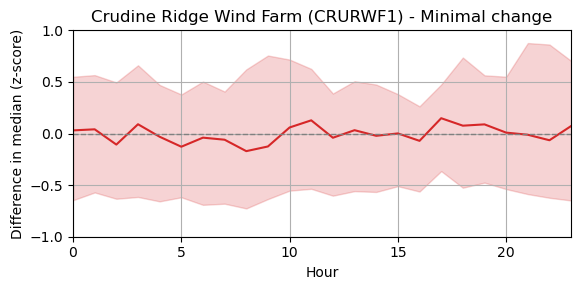

In [14]:
# Specify the DUID you want
selected_duid = "CRURWF1"

# Filter dataframe
df_single = df_cluster[df_cluster["DUID"] == selected_duid]

if df_single.empty:
    raise ValueError(f"No data found for DUID: {selected_duid}")

# Unique DUIDs (will be 1)
duids = df_single["DUID"].unique()
n = len(duids)

# Subplot layout (force 1 plot)
ncols = 1
nrows = 1

# Figure and axes
fig, ax = plt.subplots(figsize=(6, 3))

# Compute global y-limits (from the single DUID)
ymin = df_single["median_diff_lower"].min()
ymax = df_single["median_diff_upper"].max()
padding = (ymax - ymin) * 0.05
ymin -= padding
ymax += padding

# Plot
group = df_single

ax.plot(
    group["hour"],
    group["median_diff"],
    color=group["profile_color"].iloc[0],
    label=selected_duid
)

ax.fill_between(
    group["hour"],
    group["median_diff_lower"],
    group["median_diff_upper"],
    color=group["profile_color"].iloc[0],
    alpha=0.2
)

ax.set_title(
    f"{group['station_name'].iloc[0]} ({selected_duid}) - {group['profile_name'].iloc[0]}"
)
ax.set_ylabel("Difference in median (z-score)")
ax.set_xlabel("Hour")
ax.set_ylim(-1, 1)
ax.set_xlim(0,23)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(True)

plt.tight_layout()
plt.show()


In [15]:
def plot_duid_with_ci(
    df: pd.DataFrame,
    duid: str,
    metric: str = "mean",
    ax: plt.Axes | None = None
):
    """
    Plot mean/median daily curve with 95% CI for a single DUID,
    split by EHF_flag.

    Parameters
    ----------
    df : pd.DataFrame
        Tidy dataframe
    duid : str
        DUID to plot
    metric : {'mean', 'median'}
        Central tendency to plot
    ax : matplotlib.axes.Axes, optional
        Existing axes to plot into (creates new figure if None)
    """

    if metric not in {"mean", "median"}:
        raise ValueError("metric must be 'mean' or 'median'")

    df = df[df["DUID"] == duid].copy()
    if df.empty:
        raise ValueError(f"No data found for DUID {duid}")

    station_name = df["station_name"].iloc[0]

    label_map = {0: "No heatwave", 1: "Heatwave", 0.0: "No heatwave", 1.0: "Heatwave"}
    colors = ["blue", "orange"] if metric == "mean" else ["green", "red"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    for i, status in enumerate(sorted(df["EHF_flag"].unique())):
        sub = df[df["EHF_flag"] == status].sort_values("hour")

        ax.plot(
            sub["hour"],
            sub[metric],
            color=colors[i % len(colors)],
            label=label_map.get(status, str(status))
        )

        ax.fill_between(
            sub["hour"],
            sub[f"{metric}_lower"],
            sub[f"{metric}_upper"],
            color=colors[i % len(colors)],
            alpha=0.25
        )

    ax.set_title(f"{station_name} ({duid})")
    ax.set_xticks(range(0, 24, 4))
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x):02d}:00")
    )
    ax.set_xlim(0,23)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Generation (z-score)")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.legend(title="EHF status")

    plt.tight_layout()
    plt.show()



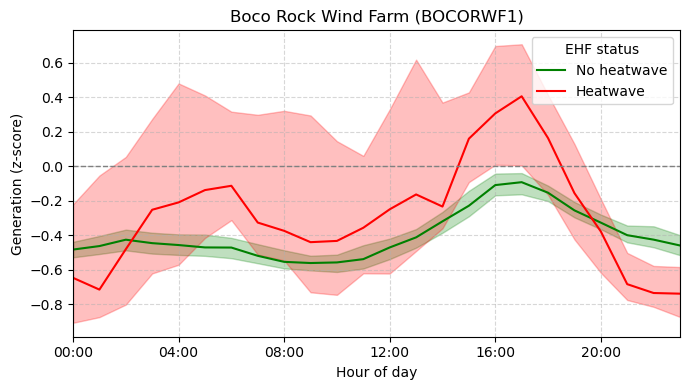

In [16]:
plot_duid_with_ci(sep, duid="BOCORWF1", metric="median")

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

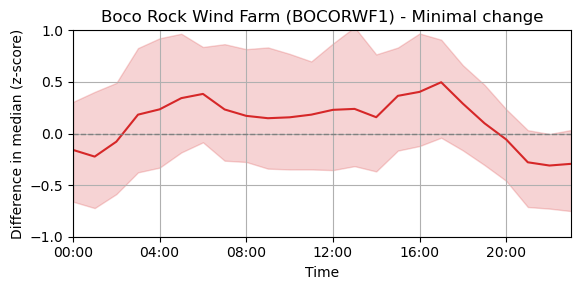

In [21]:
from matplotlib.ticker import FuncFormatter

# Specify the DUID you want
selected_duid = "BOCORWF1"

# Filter dataframe
df_single = df_cluster[df_cluster["DUID"] == selected_duid]

if df_single.empty:
    raise ValueError(f"No data found for DUID: {selected_duid}")

# Figure and axes
fig, ax = plt.subplots(figsize=(6, 3))

# Plot
group = df_single

ax.plot(
    group["hour"],
    group["median_diff"],
    color=group["profile_color"].iloc[0],
    label=selected_duid
)

ax.fill_between(
    group["hour"],
    group["median_diff_lower"],
    group["median_diff_upper"],
    color=group["profile_color"].iloc[0],
    alpha=0.2
)

ax.set_title(
    f"{group['station_name'].iloc[0]} ({selected_duid}) - {group['profile_name'].iloc[0]}"
)
ax.set_ylabel("Difference in median (z-score)")
ax.set_xlabel("Time")
ax.set_ylim(-1, 1)

# X-axis formatting as HH:00
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24, 4))  # show every 2 hours
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):02d}:00")
)
plt.setp(ax.get_xticklabels())

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.grid(True)

plt.tight_layout()
plt.show()